# Per la lettura del seguente Notebook, si consiglia di utilizzare anche la relazione relativa prodotta dal titolo "Majority_Dynamics_In_Online_Networks"

##Caricamento della rete scelta

In [1]:
#!pip install networkx matplotlib numpy pandas -q

In [2]:
!wget -q https://snap.stanford.edu/data/facebook_combined.txt.gz
!gunzip -f facebook_combined.txt.gz

In [3]:
import networkx as nx
import math
import random
import numpy as np
import pandas as pd

##EDA: Exploratory Data Analysis

In [4]:
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

print(G.number_of_nodes(), G.number_of_edges(), nx.is_connected(G))
print(f"Nodi: {G.number_of_nodes()}, Archi: {G.number_of_edges()}")

4039 88234 True
Nodi: 4039, Archi: 88234


In [5]:
degrees = [d for n, d in G.degree()]
print("Grado medio:", np.mean(degrees))
print("Grado mediano:", np.median(degrees))
print("Grado massimo:", max(degrees))
print("Coefficiente di clustering medio:", nx.average_clustering(G))
print("Densità:", nx.density(G))
print("Assortatività (per grado):", nx.degree_assortativity_coefficient(G))
print("Numero componenti connesse:", nx.number_connected_components(G))

# la componente connessa più grande, utile se il grafo è frammentato
largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()
print("Nodi nella componente principale:", G_main.number_of_nodes())

Grado medio: 43.69101262688784
Grado mediano: 25.0
Grado massimo: 1045
Coefficiente di clustering medio: 0.6055467186200862
Densità: 0.010819963503439287
Assortatività (per grado): 0.06357722918564943
Numero componenti connesse: 1
Nodi nella componente principale: 4039


In [6]:
# Calcolo del diametro e della distanza media usando un campione di nodi. La ricerca esaustiva richiederebbe più tempo
sample_nodes = np.random.choice(list(G.nodes()), size=200, replace=False)
lengths = []
for n in sample_nodes:
    lengths.extend(nx.single_source_shortest_path_length(G, n).values())
print("Distanza media stimata:", np.mean(lengths))

Distanza media stimata: 3.7103763307749444


In [7]:
from networkx.algorithms import approximation as approx
print("Diametro stimato:", approx.diameter(G))

Diametro stimato: 8


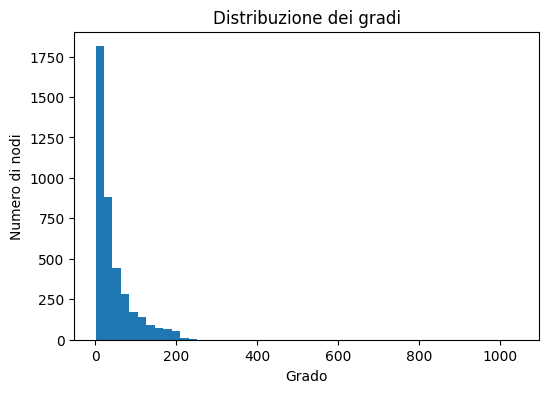

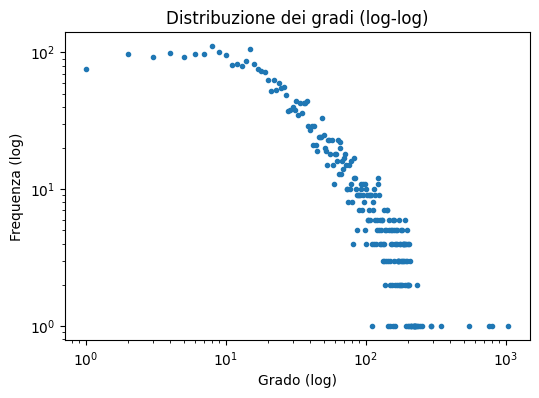

In [8]:
import matplotlib.pyplot as plt

# --- Distribuzione dei gradi ---
degrees = [d for _, d in G.degree()]
plt.figure(figsize=(6,4))
plt.hist(degrees, bins=50)
plt.xlabel("Grado"); plt.ylabel("Numero di nodi")
plt.title("Distribuzione dei gradi")
plt.show()

# in scala log-log, per vedere se assomiglia a power-law (rilevante visto il tuo corso)
degree_counts = np.bincount(degrees)
degrees_x = np.nonzero(degree_counts)[0]
plt.figure(figsize=(6,4))
plt.loglog(degrees_x, degree_counts[degrees_x], 'o', markersize=3)
plt.xlabel("Grado (log)"); plt.ylabel("Frequenza (log)")
plt.title("Distribuzione dei gradi (log-log)")
plt.show()

##Soglia di attivazione e Simulazione di Diffusione (Inf[S])

In [9]:
from collections import deque

def compute_thresholds(G):
    """Soglia di attivazione ceil(d(v)/2) per ogni nodo."""
    return {v: math.ceil(G.degree(v) / 2) for v in G.nodes()}

def simula_diffusione(G, S, thresholds=None):
    """Calcola Inf[S] con propagazione a coda (frontier), invece di riscandire tutto V ad ogni round."""
    if thresholds is None:
        thresholds = compute_thresholds(G)

    active = set(S)
    cnt = dict.fromkeys(G.nodes(), 0)
    queue = deque()

    for v in S:
        for u in G.neighbors(v):
            cnt[u] += 1
            if u not in active:
                queue.append(u)

    while queue:
        v = queue.popleft()
        if v in active:
            continue
        if cnt[v] >= thresholds[v]:
            active.add(v)
            for u in G.neighbors(v):
                if u not in active:
                    cnt[u] += 1
                    queue.append(u)

    return active

##Funzioni di costo

In [10]:
def costo_ponte(G):
    """
    Costo basato sul ruolo di 'ponte' tra community: nodi con basso
    coefficiente di clustering locale (pochi triangoli tra i propri vicini,
    quindi strutturalmente più simili a "weak ties"/structural holes)
    ricevono un costo più alto, essendo strategicamente più difficili
    da raggiungere ma potenzialmente più efficaci nel collegare community diverse.
    """
    clustering = nx.clustering(G)
    degree = dict(G.degree())
    costs = {}
    for v in G.nodes():
        c_v = clustering[v]
        d_v = degree[v]
        # scala comparabile al costo-grado: costo massimo = ceil(d(v)/2)
        # raggiunto quando clustering(v) = 0 (nodo ponte "puro")
        costs[v] = max(1, round((1 - c_v) * math.ceil(d_v / 2)))
    return costs

def costo_grado(G):
    return {v: math.ceil(G.degree(v) / 2) for v in G.nodes()}

##Algoritmo 1: Cost-Seeds-Greedy

In [11]:
def cost_seeds_greedy(G, k, cost, thresholds=None):
    """
    Algoritmo 1: Cost-Seeds-Greedy con f1.
    G: grafo NetworkX
    k: budget massimo
    cost: dict {nodo: costo}
    thresholds: dict {nodo: soglia}; se None, ceil(deg/2)
    """
    if thresholds is None:
        thresholds = compute_thresholds(G)

    cnt = dict.fromkeys(G.nodes(), 0)   # |N(v) ∩ S| corrente
    S = set()
    cost_S = 0
    candidates = set(G.nodes())

    while True:
        best_v, best_ratio = None, -1
        for v in candidates:
            gain = sum(1 for u in G.neighbors(v) if cnt[u] < thresholds[u])
            ratio = gain / cost[v]
            if ratio > best_ratio:
                best_ratio, best_v = ratio, v

        if best_v is None:
            break

        new_cost = cost_S + cost[best_v]
        if new_cost > k:
            break

        S.add(best_v)
        candidates.discard(best_v)
        cost_S = new_cost
        for u in G.neighbors(best_v):
            cnt[u] += 1

    return S

##Algoritmo 2: Weighted Target Set Selection (WTSS)

In [12]:
def wtss(G, k, cost, thresholds=None):
    """
    Algoritmo 2: WTSS, fermato al primo superamento del budget k.
    G: grafo NetworkX
    k: budget massimo
    cost: dict {nodo: costo}
    thresholds: dict {nodo: soglia t(v)}; se None, ceil(deg/2)
    """
    if thresholds is None:
        thresholds = compute_thresholds(G)

    delta = dict(G.degree())              # δ(v): grado residuo nel grafo U
    kk = dict(thresholds)                 # k(v): soglia residua
    N = {v: set(G.neighbors(v)) for v in G.nodes()}  # vicinato residuo
    U = set(G.nodes())
    S = set()
    cost_S = 0

    while U:
        # Caso 1: esiste v in U con k(v) = 0
        v1 = next((v for v in U if kk[v] == 0), None)

        if v1 is not None:
            v = v1
            for u in N[v]:
                kk[u] = max(kk[u] - 1, 0)
        else:
            # Caso 2: esiste v in U con δ(v) < k(v)
            v2 = next((v for v in U if delta[v] < kk[v]), None)

            if v2 is not None:
                v = v2
                new_cost = cost_S + cost[v]
                if new_cost > k:
                    break  # budget superato: fermo qui, S rispetta ancora k
                S.add(v)
                cost_S = new_cost
                for u in N[v]:
                    kk[u] -= 1
            else:
                # Caso 3: nessuno dei precedenti, si sceglie per rapporto
                v = max(U, key=lambda u: (cost[u] * kk[u]) / (delta[u] * (delta[u] + 1)))

        # Rimozione di v dal grafo residuo (comune a tutti e tre i casi)
        for u in N[v]:
            delta[u] -= 1
            N[u].discard(v)
        U.discard(v)

    return S

## Algoritmo 3 (Proposto): Real-Gain Greedy

###Identificazione di comunità

In [13]:
from networkx.algorithms.community import louvain_communities
communities_fb = louvain_communities(G, seed=42)
print(f"Numero di community trovate: {len(communities_fb)}")
print(f"Dimensioni: {sorted([len(c) for c in communities_fb], reverse=True)}")

Numero di community trovate: 16
Dimensioni: [548, 535, 435, 431, 423, 350, 324, 237, 226, 206, 128, 73, 60, 25, 19, 19]


###Costruzione del pool

In [14]:
import math

def build_diverse_pool(G, communities, scala='sqrt', min_per_community=1):

    n = G.number_of_nodes()
    if scala == 'sqrt':
        target_size = max(1, round(math.sqrt(n)))
    elif scala == 'log':
        target_size = max(1, round(math.log(n) * 10))  # fattore di scala da tarare
    else:
        raise ValueError("scala deve essere 'sqrt' o 'log'")

    pool = set()
    for community in communities:
        quota = max(min_per_community, round(target_size * len(community) / n))
        top_in_community = sorted(community, key=lambda v: G.degree(v), reverse=True)[:quota]
        pool.update(top_in_community)

    return pool

### Algoritmo 3 (Proposto): Real-Gain Greedy

In [15]:
def real_gain_greedy(G, k, cost, pool, thresholds=None):
    """
    Algoritmo 3: Real-Gain Greedy, con pool di candidati passato dall'esterno
    (costruito con build_diverse_pool per garantire diversificazione per community).

    A differenza di CSG (che si ferma al primo candidato non conveniente), RGG continua a cercare il
    miglior candidato nel pool residuo, fermandosi solo quando
    nessun nodo del pool rientra nel budget residuo. Questa scelta è motivata
    dal fatto che, operando su un pool ridotto (non su tutto V), fermarsi al
    primo best-ratio inammissibile porterebbe a seed set fortemente sub-ottimali
    """
    if thresholds is None:
        thresholds = compute_thresholds(G)

    S = set()
    cost_S = 0
    candidates = set(pool)
    Inf_S = simula_diffusione(G, S, thresholds)

    while True:
        best_v, best_ratio, best_Inf = None, -1, None

        for v in candidates:
            residual = k - cost_S
            if cost[v] > residual:
                continue  # scarta i candidati non fattibili, non interrompe il ciclo

            Inf_new = simula_diffusione(G, S | {v}, thresholds)
            gain = len(Inf_new) - len(Inf_S)
            ratio = gain / cost[v]
            if ratio > best_ratio:
                best_ratio, best_v, best_Inf = ratio, v, Inf_new

        if best_v is None:
            break  # nessun candidato fattibile rimasto nel pool: fine

        S.add(best_v)
        candidates.discard(best_v)
        cost_S += cost[best_v]
        Inf_S = best_Inf

    return S

##Step 1: Uso dei 3 algoritmi sulla rete scelta

In [16]:
# Soglie di attivazione per ogni nodo
thresholds = compute_thresholds(G)

# Community detection (Louvain) + pool diversificato per Real-Gain Greedy
communities_fb = louvain_communities(G, seed=42)
pool = build_diverse_pool(G, communities_fb)

print(f"Soglie calcolate per {len(thresholds)} nodi")
print(f"Numero di community trovate: {len(communities_fb)}")
print("Dimensioni delle community:", sorted((len(c) for c in communities_fb), reverse=True))
print(f"Dimensione del pool per RGG: {len(pool)}")

Soglie calcolate per 4039 nodi
Numero di community trovate: 16
Dimensioni delle community: [548, 535, 435, 431, 423, 350, 324, 237, 226, 206, 128, 73, 60, 25, 19, 19]
Dimensione del pool per RGG: 67


In [17]:
budgets = [500, 1000]
cost_functions = {'grado': costo_grado(G), 'ponte': costo_ponte(G)}

algorithms = {
    'CSG':  lambda k, cost: cost_seeds_greedy(G, k, cost, thresholds),
    'WTSS': lambda k, cost: wtss(G, k, cost, thresholds),
    'RGG':  lambda k, cost: real_gain_greedy(G, k, cost, pool, thresholds),
}

campioni = {}  # chiave: (algoritmo, costo, k) -> dict con S, Inf_S, metriche

for nome_costo, cost in cost_functions.items():
    for k in budgets:
        for nome_algo, algo_fn in algorithms.items():
            S = algo_fn(k, cost)
            Inf_S = simula_diffusione(G, S, thresholds)
            cost_S = sum(cost[v] for v in S)

            campioni[(nome_algo, nome_costo, k)] = {
                'S': S,
                'Inf_S': Inf_S,
                'cost_S': cost_S,
            }

            print(f"{nome_algo:6s} | {nome_costo:6s} | k={k:5d} | |S|={len(S):4d} | "
                  f"cost(S)={cost_S:5d} | |Inf[S]|={len(Inf_S):5d} "
                  f"({len(Inf_S)/G.number_of_nodes()*100:5.1f}%)")

print(f"\nTotale campioni generati: {len(campioni)}")

CSG    | grado  | k=  500 | |S|=  61 | cost(S)=  500 | |Inf[S]|=   72 (  1.8%)
WTSS   | grado  | k=  500 | |S|=  53 | cost(S)=  499 | |Inf[S]|=   76 (  1.9%)
RGG    | grado  | k=  500 | |S|=   9 | cost(S)=  497 | |Inf[S]|=  106 (  2.6%)
CSG    | grado  | k= 1000 | |S|= 140 | cost(S)=  992 | |Inf[S]|=  346 (  8.6%)
WTSS   | grado  | k= 1000 | |S|= 102 | cost(S)=  993 | |Inf[S]|=  356 (  8.8%)
RGG    | grado  | k= 1000 | |S|=  14 | cost(S)=  992 | |Inf[S]|=  158 (  3.9%)
CSG    | ponte  | k=  500 | |S|= 167 | cost(S)=  492 | |Inf[S]|=  216 (  5.3%)
WTSS   | ponte  | k=  500 | |S|= 209 | cost(S)=  499 | |Inf[S]|=  384 (  9.5%)
RGG    | ponte  | k=  500 | |S|=  13 | cost(S)=  494 | |Inf[S]|=  113 (  2.8%)
CSG    | ponte  | k= 1000 | |S|= 268 | cost(S)=  997 | |Inf[S]|=  335 (  8.3%)
WTSS   | ponte  | k= 1000 | |S|= 255 | cost(S)=  994 | |Inf[S]|=  430 ( 10.6%)
RGG    | ponte  | k= 1000 | |S|=  20 | cost(S)=  989 | |Inf[S]|=  169 (  4.2%)

Totale campioni generati: 12


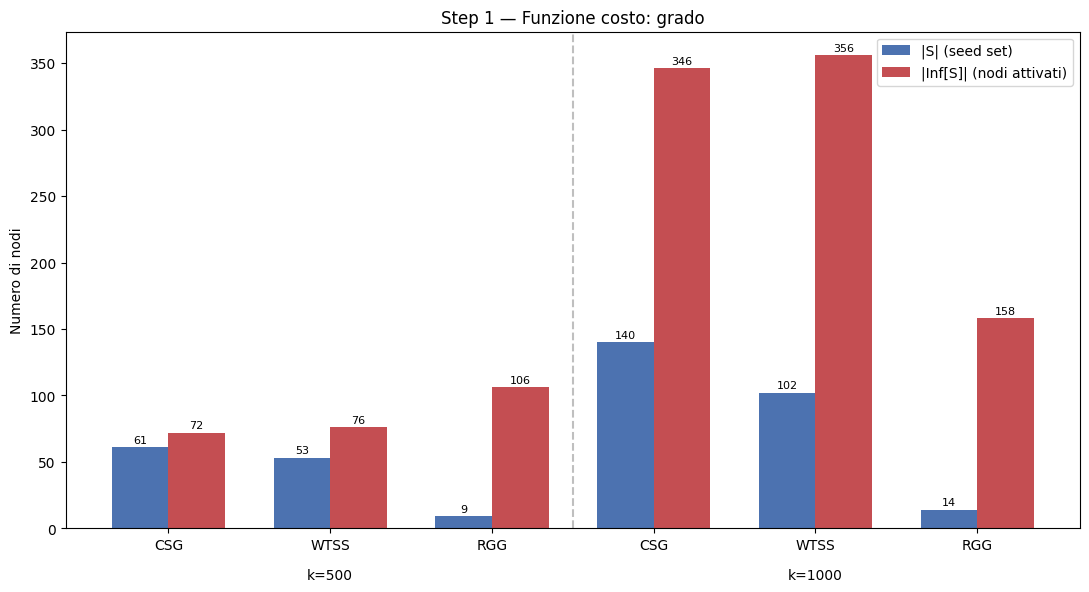

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_step1(nome_costo, campioni, budgets, algoritmi_ordine=('CSG', 'WTSS', 'RGG')):
    """
    Grafico a barre raggruppate per una funzione costo fissata:
    6 gruppi (algoritmo x k), ogni gruppo mostra |S| e |Inf[S]|.
    """
    labels = []
    seed_sizes = []
    inf_sizes = []

    for k in budgets:
        for algo in algoritmi_ordine:
            dati = campioni[(algo, nome_costo, k)]
            labels.append(f"{algo}")  # MODIFICATA
            seed_sizes.append(len(dati['S']))
            inf_sizes.append(len(dati['Inf_S']))

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))
    bars1 = ax.bar(x - width/2, seed_sizes, width, label='|S| (seed set)', color='#4C72B0')
    bars2 = ax.bar(x + width/2, inf_sizes, width, label='|Inf[S]| (nodi attivati)', color='#C44E52')

    ax.set_ylabel('Numero di nodi')
    ax.set_title(f'Step 1 — Funzione costo: {nome_costo}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    # k mostrato una sola volta al centro di ciascun gruppo
    for i, k in enumerate(budgets):  # AGGIUNTA
        centro_gruppo = i * len(algoritmi_ordine) + (len(algoritmi_ordine) - 1) / 2
        ax.text(centro_gruppo, -0.08, f'k={k}',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10)

    for bars in (bars1, bars2):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f'{h}', xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', fontsize=8)

    # separatore visivo tra i due gruppi di k
    ax.axvline(x=len(algoritmi_ordine) - 0.5, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

budgets = [500, 1000]
plot_step1('grado', campioni, budgets)

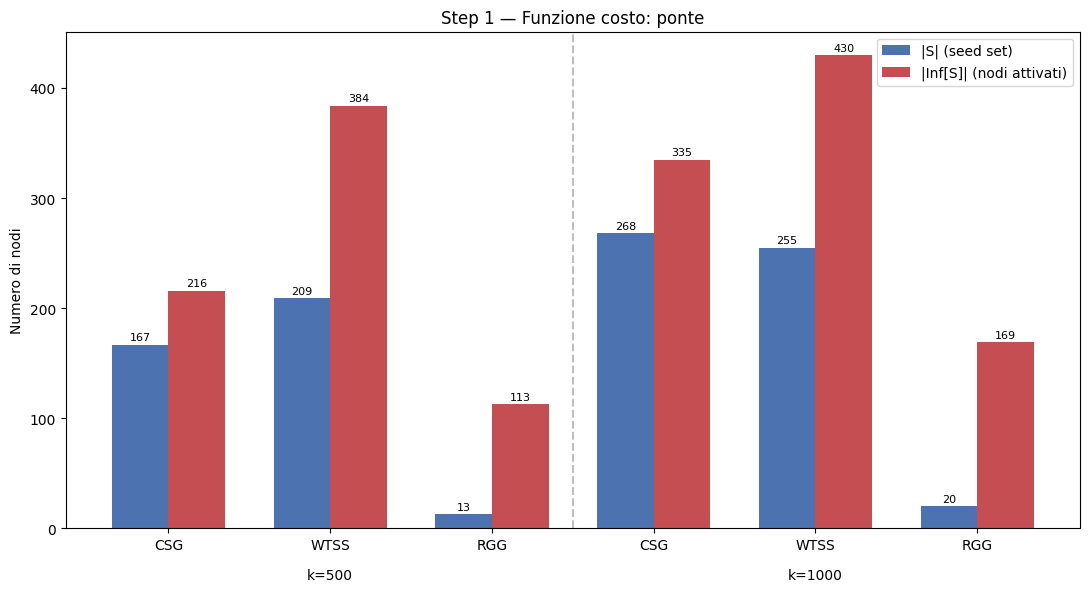

In [19]:
plot_step1('ponte', campioni, budgets)

##Step 2: Rimozione Archi

### Protezione S

In [20]:
def pool_archi_rimovibili(G, S):
    """
    Tutti gli archi di E rimovibili, incluse le connessioni dirette
    con nodi di S. Il vincolo è solo sui NODI di S (che restano protetti
    per costruzione, dato che rimuovere un arco non rimuove mai un nodo).
    """
    return list(G.edges())

###Rimozione archi

In [21]:
def rimuovi_archi(G, S, x, seed=None):
    """
    Rimuove x archi scelti a caso da tutto E (nessuna esclusione basata su S)
    Restituisce una copia del grafo con gli archi rimossi.
    """
    rng = random.Random(seed)
    pool = pool_archi_rimovibili(G, S)  # ora coincide con list(G.edges())

    if x > len(pool):
        print(f"[warning] x={x} > pool disponibile ({len(pool)}); rimuovo tutto il pool.")
        x = len(pool)

    archi_da_rimuovere = rng.sample(pool, x)

    G_pert = G.copy()
    G_pert.remove_edges_from(archi_da_rimuovere)
    return G_pert

In [22]:
percentuali_x = [0.05, 0.20]

pool_size_archi = len(pool_archi_rimovibili(G, set()))  # ora costante, indipendente da S
reti_rimozione_archi = {}

for (algo, nome_costo, k), dati in campioni.items():
    S = dati['S']

    for pct in percentuali_x:
        x = round(pool_size_archi * pct)
        G_pert = rimuovi_archi(G, S, x, seed=42)

        chiave = (algo, nome_costo, k, pct)
        nome_rete = f"G_rimozione_archi_{algo}_{nome_costo}_k{k}_pct{int(pct*100)}"

        reti_rimozione_archi[chiave] = {
            'nome': nome_rete,
            'G_pert': G_pert,
            'x_assoluto': x,
            'pool_size': pool_size_archi,
        }

        print(f"{nome_rete:45s} | pool={pool_size_archi:6d} | x={x:6d} ({pct*100:.0f}%) | "
              f"archi residui: {G_pert.number_of_edges()}")

print(f"\nTotale reti generate: {len(reti_rimozione_archi)}")

G_rimozione_archi_CSG_grado_k500_pct5         | pool= 88234 | x=  4412 (5%) | archi residui: 83822
G_rimozione_archi_CSG_grado_k500_pct20        | pool= 88234 | x= 17647 (20%) | archi residui: 70587
G_rimozione_archi_WTSS_grado_k500_pct5        | pool= 88234 | x=  4412 (5%) | archi residui: 83822
G_rimozione_archi_WTSS_grado_k500_pct20       | pool= 88234 | x= 17647 (20%) | archi residui: 70587
G_rimozione_archi_RGG_grado_k500_pct5         | pool= 88234 | x=  4412 (5%) | archi residui: 83822
G_rimozione_archi_RGG_grado_k500_pct20        | pool= 88234 | x= 17647 (20%) | archi residui: 70587
G_rimozione_archi_CSG_grado_k1000_pct5        | pool= 88234 | x=  4412 (5%) | archi residui: 83822
G_rimozione_archi_CSG_grado_k1000_pct20       | pool= 88234 | x= 17647 (20%) | archi residui: 70587
G_rimozione_archi_WTSS_grado_k1000_pct5       | pool= 88234 | x=  4412 (5%) | archi residui: 83822
G_rimozione_archi_WTSS_grado_k1000_pct20      | pool= 88234 | x= 17647 (20%) | archi residui: 70587
G_rim

In [23]:
# Controllo: quanti archi residui hanno in media i nodi di S dopo la perturbazione?
for chiave, dati_rete in reti_rimozione_archi.items():
    algo, nome_costo, k, pct = chiave
    S = campioni[(algo, nome_costo, k)]['S']
    G_pert = dati_rete['G_pert']
    gradi_S = [G_pert.degree(v) for v in S]
    print(f"{dati_rete['nome']:45s} | grado medio S in G': {np.mean(gradi_S):.1f} "
          f"(min={min(gradi_S)}, max={max(gradi_S)})")

G_rimozione_archi_CSG_grado_k500_pct5         | grado medio S in G': 15.6 (min=1, max=76)
G_rimozione_archi_CSG_grado_k500_pct20        | grado medio S in G': 13.0 (min=0, max=66)
G_rimozione_archi_WTSS_grado_k500_pct5        | grado medio S in G': 17.6 (min=1, max=66)
G_rimozione_archi_WTSS_grado_k500_pct20       | grado medio S in G': 14.8 (min=0, max=59)
G_rimozione_archi_RGG_grado_k500_pct5         | grado medio S in G': 105.1 (min=20, max=333)
G_rimozione_archi_RGG_grado_k500_pct20        | grado medio S in G': 91.6 (min=15, max=292)
G_rimozione_archi_CSG_grado_k1000_pct5        | grado medio S in G': 13.5 (min=1, max=76)
G_rimozione_archi_CSG_grado_k1000_pct20       | grado medio S in G': 11.4 (min=0, max=66)
G_rimozione_archi_WTSS_grado_k1000_pct5       | grado medio S in G': 18.1 (min=1, max=77)
G_rimozione_archi_WTSS_grado_k1000_pct20      | grado medio S in G': 15.4 (min=0, max=62)
G_rimozione_archi_RGG_grado_k1000_pct5        | grado medio S in G': 134.6 (min=20, max=525)
G_

In [24]:
risultati_rimozione_archi = {}

for chiave, dati_rete in reti_rimozione_archi.items():
    algo, nome_costo, k, pct = chiave
    G_pert = dati_rete['G_pert']
    S = campioni[(algo, nome_costo, k)]['S']

    Inf_G = campioni[(algo, nome_costo, k)]['Inf_S']       # riferimento su G originale
    Inf_G_pert = simula_diffusione(G_pert, S, thresholds)  # su G_rimozione_archi

    delta = len(Inf_G) - len(Inf_G_pert)
    delta_pct = delta / len(Inf_G) * 100 if len(Inf_G) > 0 else 0

    risultati_rimozione_archi[chiave] = {
        'Inf_G_pert': Inf_G_pert,
        'size_Inf_G': len(Inf_G),
        'size_Inf_G_pert': len(Inf_G_pert),
        'delta': delta,
        'delta_pct': delta_pct,
    }

    print(f"{dati_rete['nome']:45s} | |Inf[G,S]|={len(Inf_G):5d} | "
          f"|Inf[G',S]|={len(Inf_G_pert):5d} | Δ={delta:+5d} ({delta_pct:+.1f}%)")

G_rimozione_archi_CSG_grado_k500_pct5         | |Inf[G,S]|=   72 | |Inf[G',S]|=   72 | Δ=   +0 (+0.0%)
G_rimozione_archi_CSG_grado_k500_pct20        | |Inf[G,S]|=   72 | |Inf[G',S]|=   70 | Δ=   +2 (+2.8%)
G_rimozione_archi_WTSS_grado_k500_pct5        | |Inf[G,S]|=   76 | |Inf[G',S]|=   67 | Δ=   +9 (+11.8%)
G_rimozione_archi_WTSS_grado_k500_pct20       | |Inf[G,S]|=   76 | |Inf[G',S]|=   58 | Δ=  +18 (+23.7%)
G_rimozione_archi_RGG_grado_k500_pct5         | |Inf[G,S]|=  106 | |Inf[G',S]|=  102 | Δ=   +4 (+3.8%)
G_rimozione_archi_RGG_grado_k500_pct20        | |Inf[G,S]|=  106 | |Inf[G',S]|=   84 | Δ=  +22 (+20.8%)
G_rimozione_archi_CSG_grado_k1000_pct5        | |Inf[G,S]|=  346 | |Inf[G',S]|=  345 | Δ=   +1 (+0.3%)
G_rimozione_archi_CSG_grado_k1000_pct20       | |Inf[G,S]|=  346 | |Inf[G',S]|=  157 | Δ= +189 (+54.6%)
G_rimozione_archi_WTSS_grado_k1000_pct5       | |Inf[G,S]|=  356 | |Inf[G',S]|=  132 | Δ= +224 (+62.9%)
G_rimozione_archi_WTSS_grado_k1000_pct20      | |Inf[G,S]|=  356 | |

In [25]:
# Diagnostica sul caso più estremo: WTSS/grado/k1000/pct20
S = campioni[('WTSS', 'grado', 1000)]['S']
G_pert = reti_rimozione_archi[('WTSS', 'grado', 1000, 0.20)]['G_pert']
Inf_G = campioni[('WTSS', 'grado', 1000)]['Inf_S']
Inf_G_pert = risultati_rimozione_archi[('WTSS', 'grado', 1000, 0.20)]['Inf_G_pert']

nodi_persi = Inf_G - Inf_G_pert
print(f"Nodi attivi in G ma non in G': {len(nodi_persi)}")

# Per i nodi persi, quanto erano "vicini" alla soglia in G originale?
margini = []
for v in nodi_persi:
    if v in S:
        continue
    vicini_attivi_G = sum(1 for u in G.neighbors(v) if u in Inf_G)
    margine = vicini_attivi_G - thresholds[v]
    margini.append(margine)

import numpy as np
print(f"Margine medio rispetto a soglia (vicini attivi - soglia) per nodi persi: {np.mean(margini):.2f}")
print(f"Margine minimo: {np.min(margini)}, massimo: {np.max(margini)}")

Nodi attivi in G ma non in G': 239
Margine medio rispetto a soglia (vicini attivi - soglia) per nodi persi: 8.20
Margine minimo: 0, massimo: 166


In [26]:
import numpy as np

margini_arr = np.array(margini)
print(f"n={len(margini_arr)}")
print(f"Mediana: {np.median(margini_arr):.1f}")
print(f"Percentili: 10°={np.percentile(margini_arr,10):.1f}, "
      f"25°={np.percentile(margini_arr,25):.1f}, "
      f"75°={np.percentile(margini_arr,75):.1f}, "
      f"90°={np.percentile(margini_arr,90):.1f}")
print(f"Quanti con margine <= 1: {np.sum(margini_arr <= 1)} ({np.mean(margini_arr<=1)*100:.1f}%)")
print(f"Quanti con margine <= 3: {np.sum(margini_arr <= 3)} ({np.mean(margini_arr<=3)*100:.1f}%)")
print(f"Quanti con margine >= 20: {np.sum(margini_arr >= 20)} ({np.mean(margini_arr>=20)*100:.1f}%)")

n=239
Mediana: 5.0
Percentili: 10°=1.0, 25°=2.0, 75°=10.0, 90°=19.2
Quanti con margine <= 1: 51 (21.3%)
Quanti con margine <= 3: 95 (39.7%)
Quanti con margine >= 20: 24 (10.0%)


In [27]:
# Tra i nodi persi, quanti sono raggiungibili nel grafo perturbato G'
# partendo da S, ignorando le soglie (pura connettività)?
import networkx as nx

raggiungibili_pert = set()
for s in S:
    if s in G_pert:
        raggiungibili_pert |= nx.node_connected_component(G_pert, s)

nodi_persi_isolati = nodi_persi - raggiungibili_pert
print(f"Nodi persi diventati IRRAGGIUNGIBILI da S in G' (componente disconnessa): {len(nodi_persi_isolati)}")
print(f"Nodi persi ma ancora raggiungibili (falliti solo per soglia/ordine): {len(nodi_persi) - len(nodi_persi_isolati)}")

Nodi persi diventati IRRAGGIUNGIBILI da S in G' (componente disconnessa): 4
Nodi persi ma ancora raggiungibili (falliti solo per soglia/ordine): 235


###Grafici relativi alla rimozione archi

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rimozione(step, nome_costo, pct, campioni, risultati, tipo,
                    budgets=(500, 1000), algoritmi_ordine=('CSG', 'WTSS', 'RGG')):
    """
    Grafico a barre raggruppate per funzione costo e percentuale fissate:
    6 gruppi (algoritmo x k), ogni gruppo mostra |Inf[G,S]| e |Inf[G',S]|.
    """
    labels = []
    inf_G = []
    inf_G_pert = []

    for k in budgets:
        for algo in algoritmi_ordine:
            chiave_campione = (algo, nome_costo, k)
            chiave_risultato = (algo, nome_costo, k, pct)

            inf_G.append(len(campioni[chiave_campione]['Inf_S']))
            inf_G_pert.append(risultati[chiave_risultato]['size_Inf_G_pert'])
            labels.append(f"{algo}")

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))
    bars1 = ax.bar(x - width/2, inf_G, width, label='|Inf[G,S]| (originale)', color='#4C72B0')
    bars2 = ax.bar(x + width/2, inf_G_pert, width, label=f"|Inf[G',S]| (post rimozione {tipo})", color='#C44E52')

    ax.set_ylabel('Numero di nodi attivati')
    ax.set_title(f"Step {step} — Funzione costo: {nome_costo}, Rimozione del {int(pct*100)}% di {tipo}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    for i, k in enumerate(budgets):
        centro_gruppo = i * len(algoritmi_ordine) + (len(algoritmi_ordine) - 1) / 2
        ax.text(centro_gruppo, -0.08, f'k={k}',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10)

    for bars in (bars1, bars2):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f'{h}', xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', fontsize=8)

    ax.axvline(x=len(algoritmi_ordine) - 0.5, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

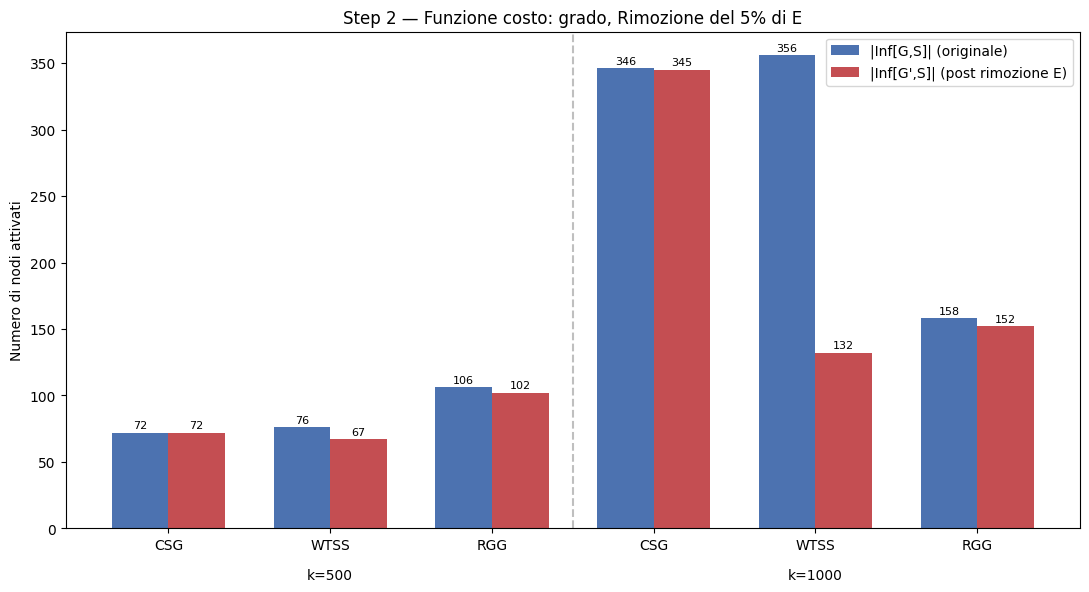

In [29]:
plot_rimozione(2, 'grado', 0.05, campioni, risultati_rimozione_archi, 'E')

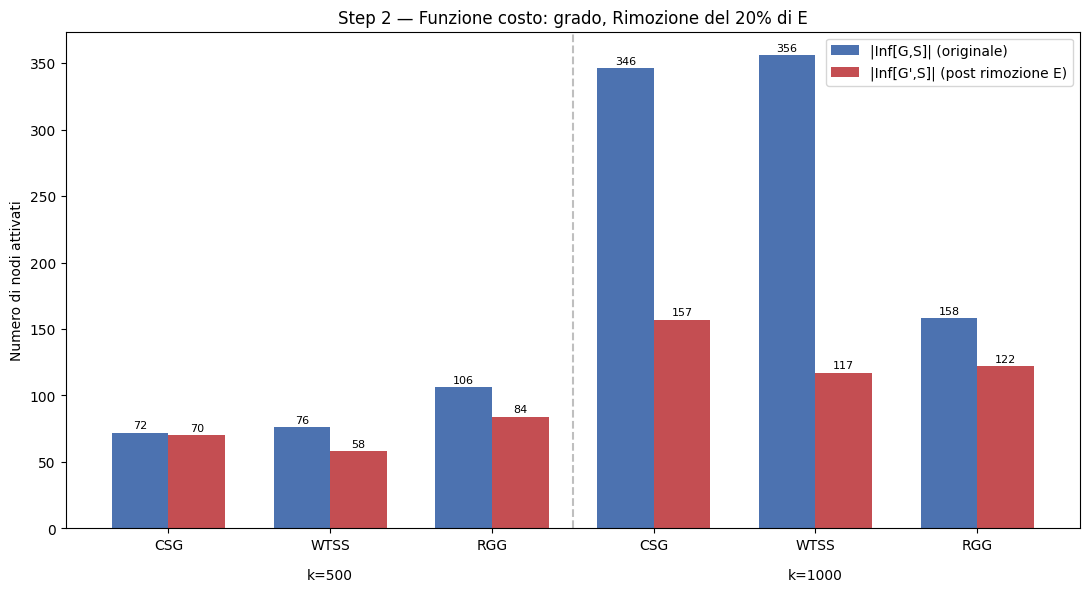

In [30]:
plot_rimozione(2, 'grado', 0.2, campioni, risultati_rimozione_archi, 'E')

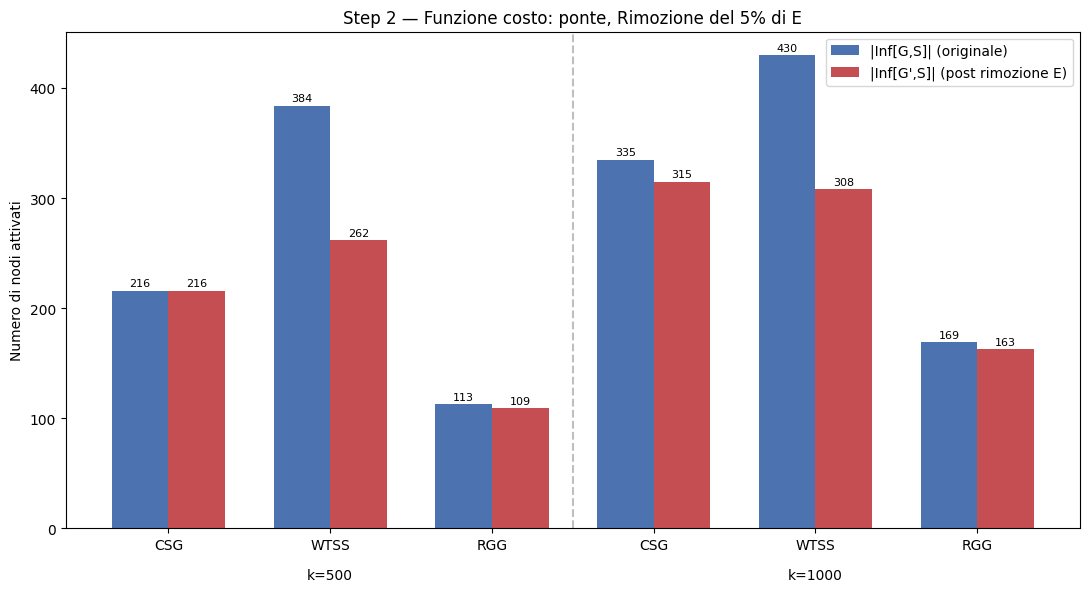

In [31]:
plot_rimozione(2, 'ponte', 0.05, campioni, risultati_rimozione_archi, 'E')

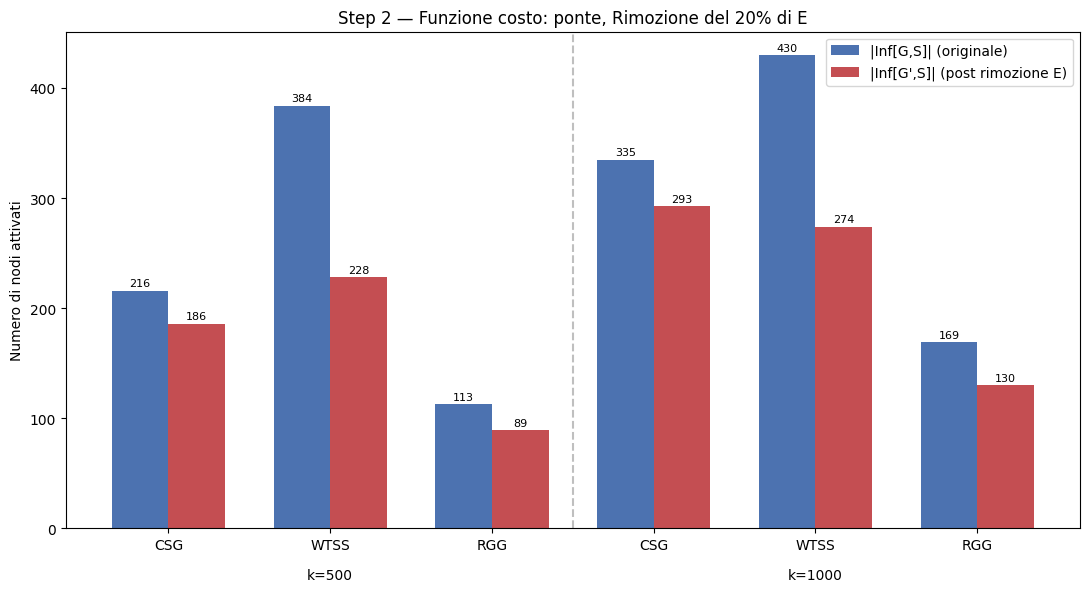

In [32]:
plot_rimozione(2, 'ponte', 0.2, campioni, risultati_rimozione_archi, 'E')

##Step 3 Rimozione vertici

###Fase preliminare

In [33]:
def pool_vertici_rimovibili(G, S):
    """
    Tutti i nodi di V - S sono rimovibili, senza vincolo di distanza.
    L'unico vincolo è non rimuovere i nodi di S stessi.
    """
    return [v for v in G.nodes() if v not in S]

In [34]:
# Diagnostica: dimensione del pool di vertici rimovibili per ciascun campione
print(f"{'algo':6s} {'costo':6s} {'k':6s} {'|S|':5s} {'|V| totale':11s} {'pool rimovibile':16s} {'% pool su |V|'}")
for (algo, costo, k), dati in campioni.items():
    S = dati['S']
    pool_v = pool_vertici_rimovibili(G, S)
    print(f"{algo:6s} {costo:6s} {k:<6d} {len(S):<5d} {G.number_of_nodes():<11d} "
          f"{len(pool_v):<16d} {len(pool_v)/G.number_of_nodes()*100:5.1f}%")

algo   costo  k      |S|   |V| totale  pool rimovibile  % pool su |V|
CSG    grado  500    61    4039        3978              98.5%
WTSS   grado  500    53    4039        3986              98.7%
RGG    grado  500    9     4039        4030              99.8%
CSG    grado  1000   140   4039        3899              96.5%
WTSS   grado  1000   102   4039        3937              97.5%
RGG    grado  1000   14    4039        4025              99.7%
CSG    ponte  500    167   4039        3872              95.9%
WTSS   ponte  500    209   4039        3830              94.8%
RGG    ponte  500    13    4039        4026              99.7%
CSG    ponte  1000   268   4039        3771              93.4%
WTSS   ponte  1000   255   4039        3784              93.7%
RGG    ponte  1000   20    4039        4019              99.5%


In [35]:
import random

def stima_archi_rimossi_da_vertici(G, pool, y, seed=42):
    """
    Stima (senza modificare G) quanti archi verrebbero rimossi
    se si rimuovessero y nodi a caso dal pool, contando gli archi incidenti
    (con deduplicazione se due nodi rimossi sono adiacenti tra loro).
    """
    rng = random.Random(seed)
    if y > len(pool):
        y = len(pool)
    nodi_scelti = set(rng.sample(pool, y))

    archi_coinvolti = set()
    for v in nodi_scelti:
        for u in G.neighbors(v):
            archi_coinvolti.add(frozenset((u, v)))

    return len(archi_coinvolti)


print(f"{'algo':6s} {'costo':6s} {'k':6s} {'pool':6s} "
      f"{'y@5%':6s} {'archi persi':12s} {'y@20%':7s} {'archi persi':12s}")

for (algo, costo, k), dati in campioni.items():
    S = dati['S']
    pool_v = pool_vertici_rimovibili(G, S)
    pool_size = len(pool_v)

    y5 = round(pool_size * 0.05)
    y20 = round(pool_size * 0.20)

    archi5 = stima_archi_rimossi_da_vertici(G, pool_v, y5)
    archi20 = stima_archi_rimossi_da_vertici(G, pool_v, y20)

    print(f"{algo:6s} {costo:6s} {k:<6d} {pool_size:<6d} "
          f"{y5:<6d} {archi5:<12d} {y20:<7d} {archi20:<12d} "
          f"({archi20/G.number_of_edges()*100:.1f}% di |E|)")

algo   costo  k      pool   y@5%   archi persi  y@20%   archi persi 
CSG    grado  500    3978   199    9536         796     34189        (38.7% di |E|)
WTSS   grado  500    3986   199    8650         797     32012        (36.3% di |E|)
RGG    grado  500    4030   202    9444         806     31545        (35.8% di |E|)
CSG    grado  1000   3899   195    7308         780     29833        (33.8% di |E|)
WTSS   grado  1000   3937   197    9241         787     31552        (35.8% di |E|)
RGG    grado  1000   4025   201    8796         805     29858        (33.8% di |E|)
CSG    ponte  500    3872   194    8356         774     30518        (34.6% di |E|)
WTSS   ponte  500    3830   192    7791         766     31786        (36.0% di |E|)
RGG    ponte  500    4026   201    9353         805     31194        (35.4% di |E|)
CSG    ponte  1000   3771   189    7817         754     30641        (34.7% di |E|)
WTSS   ponte  1000   3784   189    8157         757     31583        (35.8% di |E|)
RGG    

### Rimozione vertici effettiva

In [36]:
def rimuovi_vertici(G, S, y, seed=None):
    """
    Rimuove y vertici scelti a caso da V - S (nessuna esclusione per distanza:
    ora anche i vicini diretti di S sono rimovibili, insieme al loro
    intero vicinato).
    """
    rng = random.Random(seed)
    pool = pool_vertici_rimovibili(G, S)  # ora coincide con V - S

    if y > len(pool):
        print(f"[warning] y={y} > pool disponibile ({len(pool)}); rimuovo tutto il pool.")
        y = len(pool)

    vertici_da_rimuovere = rng.sample(pool, y)

    G_pert = G.copy()
    G_pert.remove_nodes_from(vertici_da_rimuovere)
    return G_pert

In [37]:
percentuali_y = [0.05, 0.20]
reti_rimozione_vertici = {}

for (algo, nome_costo, k), dati in campioni.items():
    S = dati['S']
    pool_v = pool_vertici_rimovibili(G, S)
    pool_size = len(pool_v)

    for pct in percentuali_y:
        y = round(pool_size * pct)
        G_pert = rimuovi_vertici(G, S, y, seed=42)  # firma coerente con Cella 1

        chiave = (algo, nome_costo, k, pct)
        nome_rete = f"G_rimozione_vertici_{algo}_{nome_costo}_k{k}_pct{int(pct*100)}"

        reti_rimozione_vertici[chiave] = {
            'nome': nome_rete,
            'G_pert': G_pert,
            'y_assoluto': y,
            'pool_size': pool_size,
        }

        print(f"{nome_rete:48s} | pool={pool_size:6d} | y={y:5d} ({pct*100:.0f}%) | "
              f"nodi residui: {G_pert.number_of_nodes()} | archi residui: {G_pert.number_of_edges()}")

print(f"\nTotale reti generate: {len(reti_rimozione_vertici)}")

G_rimozione_vertici_CSG_grado_k500_pct5          | pool=  3978 | y=  199 (5%) | nodi residui: 3840 | archi residui: 78698
G_rimozione_vertici_CSG_grado_k500_pct20         | pool=  3978 | y=  796 (20%) | nodi residui: 3243 | archi residui: 54045
G_rimozione_vertici_WTSS_grado_k500_pct5         | pool=  3986 | y=  199 (5%) | nodi residui: 3840 | archi residui: 79584
G_rimozione_vertici_WTSS_grado_k500_pct20        | pool=  3986 | y=  797 (20%) | nodi residui: 3242 | archi residui: 56222
G_rimozione_vertici_RGG_grado_k500_pct5          | pool=  4030 | y=  202 (5%) | nodi residui: 3837 | archi residui: 78790
G_rimozione_vertici_RGG_grado_k500_pct20         | pool=  4030 | y=  806 (20%) | nodi residui: 3233 | archi residui: 56689
G_rimozione_vertici_CSG_grado_k1000_pct5         | pool=  3899 | y=  195 (5%) | nodi residui: 3844 | archi residui: 80926
G_rimozione_vertici_CSG_grado_k1000_pct20        | pool=  3899 | y=  780 (20%) | nodi residui: 3259 | archi residui: 58401
G_rimozione_vertici_

In [38]:
risultati_rimozione_vertici = {}

for chiave, dati_rete in reti_rimozione_vertici.items():
    algo, nome_costo, k, pct = chiave
    G_pert = dati_rete['G_pert']
    S = campioni[(algo, nome_costo, k)]['S']

    Inf_G = campioni[(algo, nome_costo, k)]['Inf_S']       # riferimento su G originale
    Inf_G_pert = simula_diffusione(G_pert, S, thresholds)  # su G_rimozione_vertici

    delta = len(Inf_G) - len(Inf_G_pert)
    delta_pct = delta / len(Inf_G) * 100 if len(Inf_G) > 0 else 0

    risultati_rimozione_vertici[chiave] = {
        'Inf_G_pert': Inf_G_pert,
        'size_Inf_G': len(Inf_G),
        'size_Inf_G_pert': len(Inf_G_pert),
        'delta': delta,
        'delta_pct': delta_pct,
    }

    print(f"{dati_rete['nome']:48s} | |Inf[G,S]|={len(Inf_G):5d} | "
          f"|Inf[G',S]|={len(Inf_G_pert):5d} | Δ={delta:+5d} ({delta_pct:+.1f}%)")

G_rimozione_vertici_CSG_grado_k500_pct5          | |Inf[G,S]|=   72 | |Inf[G',S]|=   71 | Δ=   +1 (+1.4%)
G_rimozione_vertici_CSG_grado_k500_pct20         | |Inf[G,S]|=   72 | |Inf[G',S]|=   67 | Δ=   +5 (+6.9%)
G_rimozione_vertici_WTSS_grado_k500_pct5         | |Inf[G,S]|=   76 | |Inf[G',S]|=   76 | Δ=   +0 (+0.0%)
G_rimozione_vertici_WTSS_grado_k500_pct20        | |Inf[G,S]|=   76 | |Inf[G',S]|=   74 | Δ=   +2 (+2.6%)
G_rimozione_vertici_RGG_grado_k500_pct5          | |Inf[G,S]|=  106 | |Inf[G',S]|=  101 | Δ=   +5 (+4.7%)
G_rimozione_vertici_RGG_grado_k500_pct20         | |Inf[G,S]|=  106 | |Inf[G',S]|=   86 | Δ=  +20 (+18.9%)
G_rimozione_vertici_CSG_grado_k1000_pct5         | |Inf[G,S]|=  346 | |Inf[G',S]|=  336 | Δ=  +10 (+2.9%)
G_rimozione_vertici_CSG_grado_k1000_pct20        | |Inf[G,S]|=  346 | |Inf[G',S]|=  302 | Δ=  +44 (+12.7%)
G_rimozione_vertici_WTSS_grado_k1000_pct5        | |Inf[G,S]|=  356 | |Inf[G',S]|=  188 | Δ= +168 (+47.2%)
G_rimozione_vertici_WTSS_grado_k1000_pct20 

## Grafici relativi alla rimozione vertici

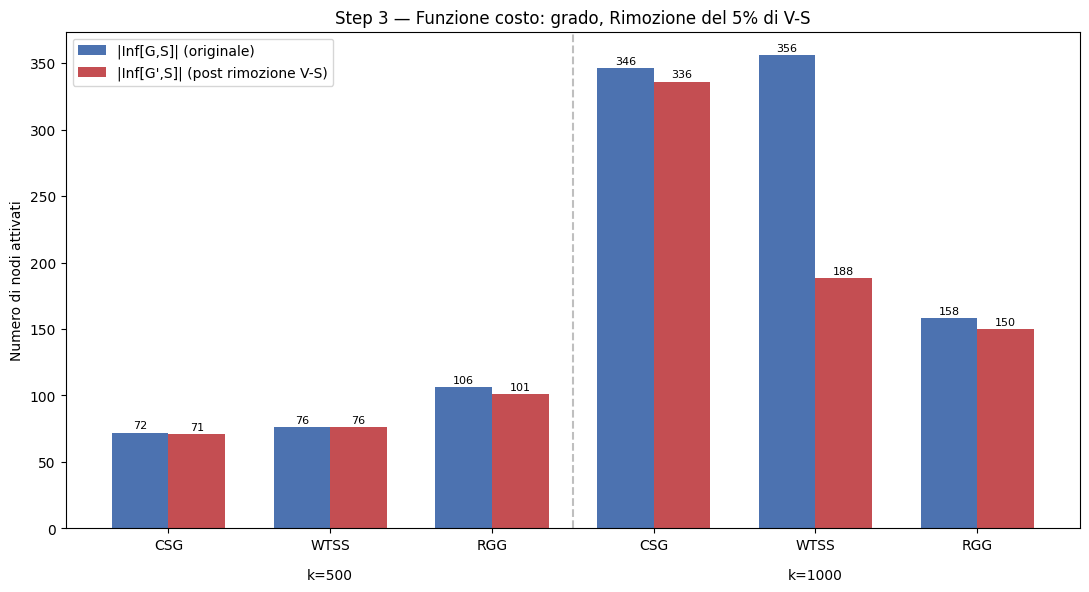

In [39]:
plot_rimozione(3, 'grado', 0.05, campioni, risultati_rimozione_vertici, 'V-S')

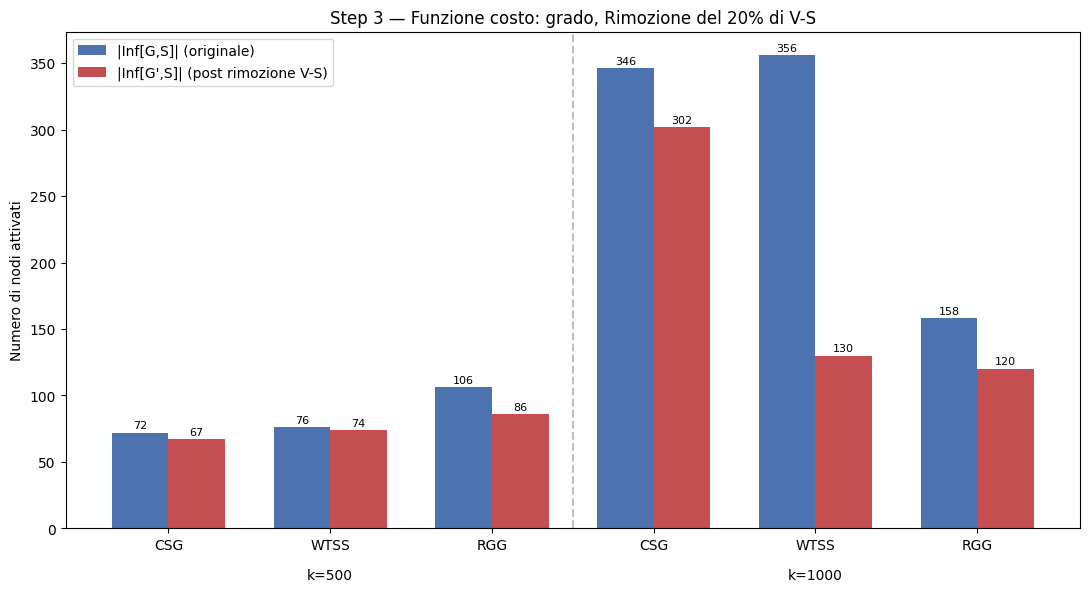

In [40]:
plot_rimozione(3, 'grado', 0.20, campioni, risultati_rimozione_vertici, 'V-S')

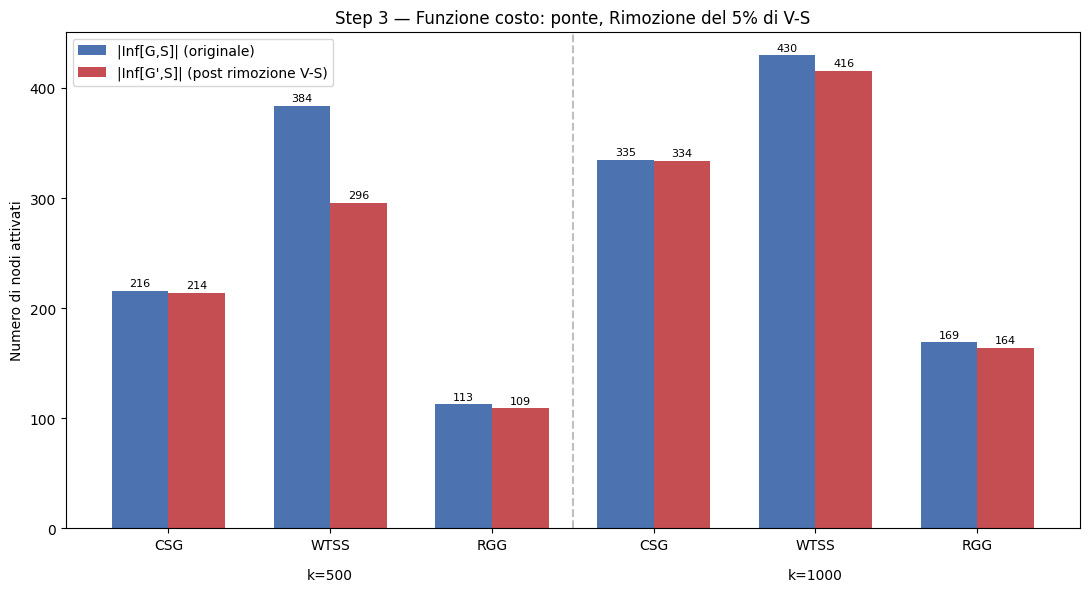

In [41]:
plot_rimozione(3,'ponte', 0.05, campioni, risultati_rimozione_vertici, 'V-S')

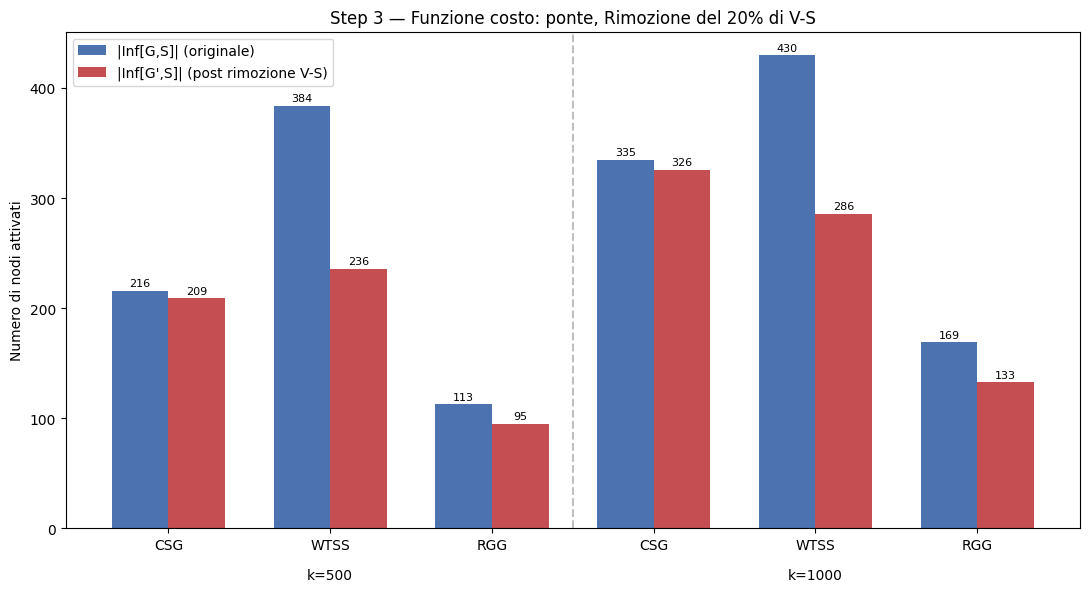

In [42]:
plot_rimozione(3, 'ponte', 0.20, campioni, risultati_rimozione_vertici, 'V-S')